In [154]:
ruta_resultados = "resultados03"

import pandas as pd
import numpy as np

# --- cargar cuaterniones ---
df_q = pd.read_csv("cuat_deltas03.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-6
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773426542807063808,0.999262,0.004128,0.000661,0.038176,1,1773426542807
1,1773426542817031680,0.999262,0.004130,0.000663,0.038174,1,1773426542817
2,1773426542826902016,0.999262,0.004135,0.000660,0.038173,1,1773426542826
3,1773426542836676608,0.999262,0.004132,0.000662,0.038171,1,1773426542836
4,1773426542846929408,0.999263,0.004135,0.000663,0.038166,1,1773426542846
...,...,...,...,...,...,...,...
1482,1773426557921251840,0.999678,0.004180,0.000023,0.025013,1,1773426557921
1483,1773426557931587584,0.999678,0.004197,0.000021,0.025009,1,1773426557931
1484,1773426557941829120,0.999678,0.004216,0.000021,0.025004,1,1773426557941
1485,1773426557951974400,0.999678,0.004240,0.000017,0.025000,1,1773426557951


In [155]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [156]:
# cargar aceleraciones
df_a = pd.read_csv("deltas03.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:deltaThetaX": "arx",
    "inertial-6286.188861:deltaThetaY": "ary",
    "inertial-6286.188861:deltaThetaZ": "arz",
    "inertial-6286.188861:deltaVelX": "alx",
    "inertial-6286.188861:deltaVelY": "aly",
    "inertial-6286.188861:deltaVelZ": "alz",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-6
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp
0,1773426542806444544,0.000021,-0.000063,-0.009959,-0.000001,3.074118e-06,4.296972e-06,1773426542806
1,1773426542816418816,0.000016,-0.000075,-0.009956,0.000003,1.724204e-06,4.320917e-06,1773426542816
2,1773426542826295552,0.000020,-0.000069,-0.009958,0.000009,-5.631823e-06,8.045944e-06,1773426542826
3,1773426542836075776,0.000025,-0.000069,-0.009965,-0.000007,3.293544e-06,3.282911e-06,1773426542836
4,1773426542846334464,0.000025,-0.000069,-0.009961,0.000005,-6.360983e-07,-1.554372e-06,1773426542846
...,...,...,...,...,...,...,...,...
1494,1773426557920577024,0.000024,-0.000043,-0.009960,0.000025,-7.898367e-06,2.836297e-06,1773426557920
1495,1773426557930919680,0.000030,-0.000039,-0.009968,0.000035,-1.028497e-05,3.862770e-06,1773426557930
1496,1773426557941166080,0.000025,-0.000041,-0.009954,0.000039,-5.392424e-06,2.317172e-06,1773426557941
1497,1773426557951317760,0.000028,-0.000042,-0.009954,0.000048,-1.231268e-05,2.744109e-06,1773426557951


In [157]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [158]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[-1.31453442e-06,  3.07411847e-06,  4.29697184e-06,
         2.11144143e-05, -6.30681971e-05, -9.95891169e-03],
       [ 3.28000874e-06,  1.72420437e-06,  4.32091701e-06,
         1.61496300e-05, -7.51333937e-05, -9.95613448e-03],
       [ 8.89703188e-06, -5.63182266e-06,  8.04594401e-06,
         2.01316343e-05, -6.85805062e-05, -9.95797943e-03],
       ...,
       [ 3.89684537e-05, -5.39242365e-06,  2.31717240e-06,
         2.51169240e-05, -4.14959723e-05, -9.95414425e-03],
       [ 4.84406737e-05, -1.23126820e-05,  2.74410900e-06,
         2.78247262e-05, -4.18163545e-05, -9.95441154e-03],
       [ 5.00575406e-05, -8.49691787e-06,  8.13600707e-07,
         2.89329746e-05, -4.86710414e-05, -9.95461736e-03]],
      shape=(1499, 6))

In [159]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[-6.34176538e-09,  1.48306030e-08,  2.07300675e-08,
         1.01863184e-07, -3.04262638e-07, -4.80452094e-05],
       [-2.45700687e-08,  1.02781873e-07,  1.52886022e-07,
         7.26730237e-07, -2.30047412e-06, -3.54056398e-04],
       [ 2.46229722e-08,  3.04311528e-07,  5.60875433e-07,
         2.50623298e-06, -8.35325201e-06, -1.25620440e-03],
       ...,
       [ 1.43454036e-05, -3.20937649e-06,  4.96116922e-07,
         2.73141914e-05, -4.10566734e-05, -9.95805829e-03],
       [ 2.35141874e-05, -5.34950999e-06,  1.28581507e-06,
         2.70797622e-05, -4.14177081e-05, -9.95779347e-03],
       [ 3.11382440e-05, -7.16387816e-06,  2.16164108e-06,
         2.68472886e-05, -4.16326405e-05, -9.95793263e-03]],
      shape=(1499, 6))

In [160]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([-1.29319223e-06,  1.46741296e-07,  1.20801593e-06, ...,
        4.16928297e-05,  4.59631562e-05,  4.99112571e-05], shape=(1499,))

In [161]:
arx

array([-1.31453442e-06,  3.28000874e-06,  8.89703188e-06, ...,
        3.89684537e-05,  4.84406737e-05,  5.00575406e-05], shape=(1499,))

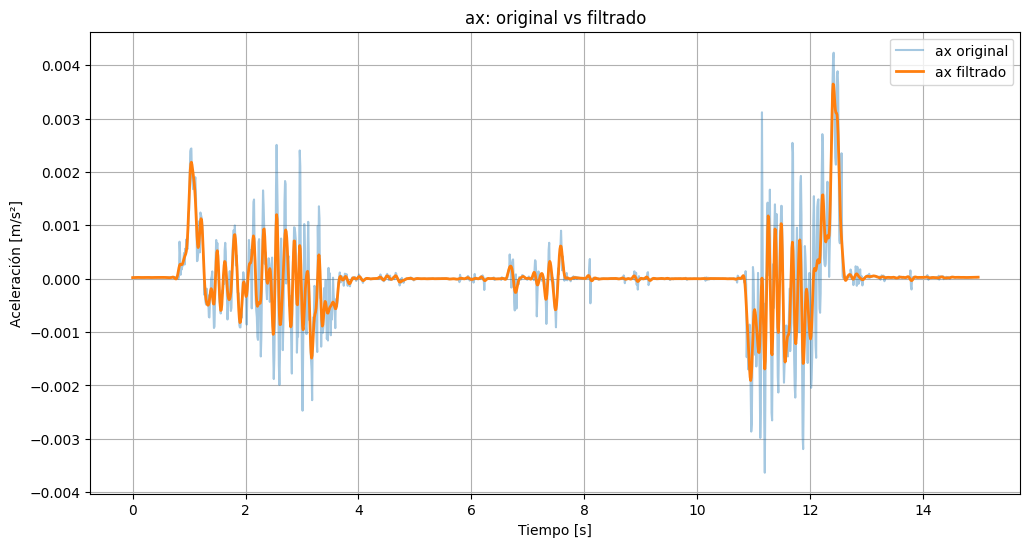

In [162]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

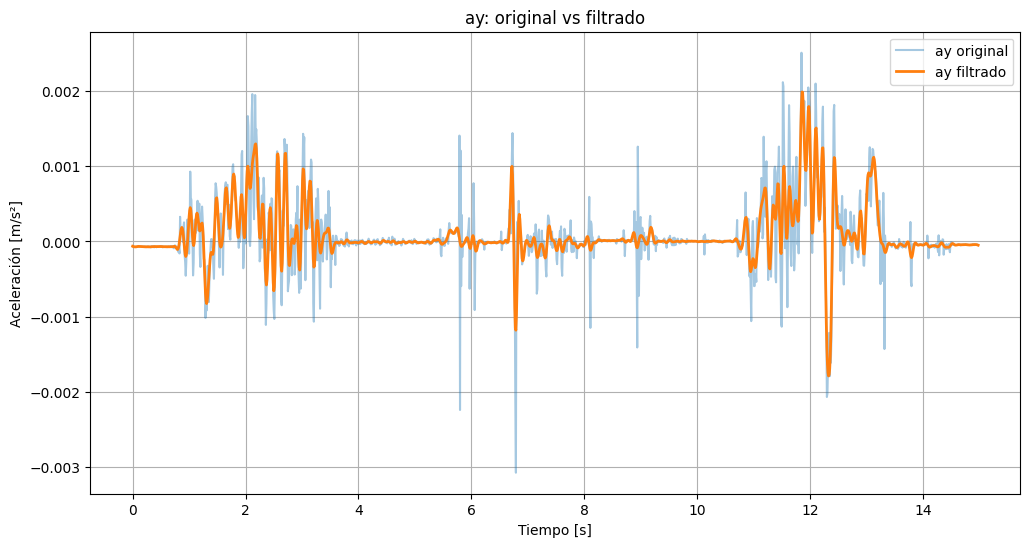

In [163]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(aly)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, aly, label='ay original', alpha=0.4)
plt.plot(t, aly_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ay: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

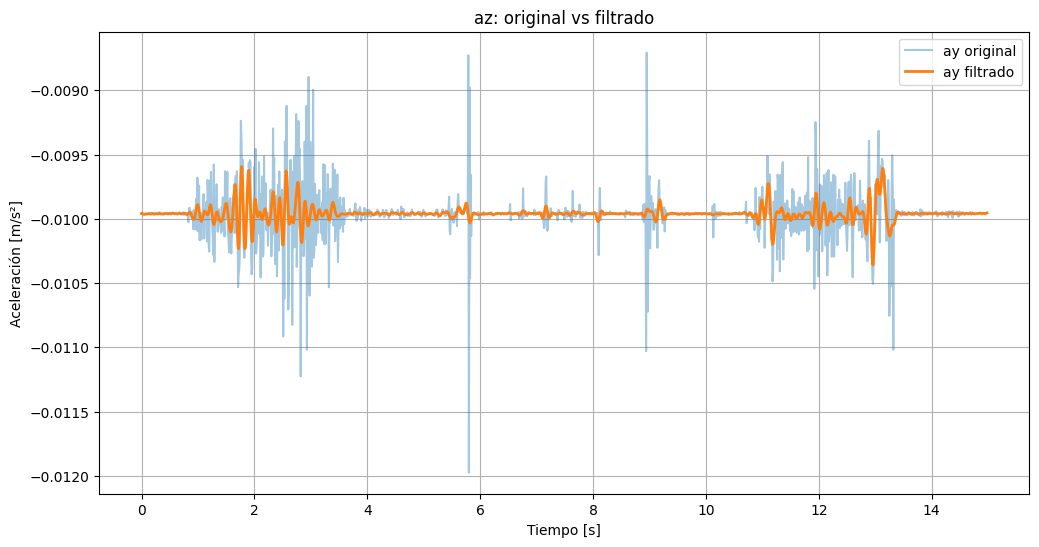

In [164]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alz)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alz, label='ay original', alpha=0.4)
plt.plot(t, alz_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("az: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [165]:
print(alx_f.shape)
df_a['arx']

(1499,)


0      -0.000001
1       0.000003
2       0.000009
3      -0.000007
4       0.000005
          ...   
1494    0.000025
1495    0.000035
1496    0.000039
1497    0.000048
1498    0.000050
Name: arx, Length: 1499, dtype: float64

In [166]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773426542806444544,0.000021,-0.000063,-0.009959,-0.000001,3.074118e-06,4.296972e-06,1773426542806,-1.293192e-06,3.040738e-06,4.294209e-06,0.000021,-0.000063,-0.009959
1,1773426542816418816,0.000016,-0.000075,-0.009956,0.000003,1.724204e-06,4.320917e-06,1773426542816,1.467413e-07,1.392403e-06,4.080293e-06,0.000022,-0.000066,-0.009960
2,1773426542826295552,0.000020,-0.000069,-0.009958,0.000009,-5.631823e-06,8.045944e-06,1773426542826,1.208016e-06,-7.980407e-09,3.874450e-06,0.000022,-0.000069,-0.009962
3,1773426542836075776,0.000025,-0.000069,-0.009965,-0.000007,3.293544e-06,3.282911e-06,1773426542836,1.640232e-06,-9.779739e-07,3.696047e-06,0.000023,-0.000071,-0.009963
4,1773426542846334464,0.000025,-0.000069,-0.009961,0.000005,-6.360983e-07,-1.554372e-06,1773426542846,1.392701e-06,-1.434560e-06,3.576604e-06,0.000024,-0.000072,-0.009963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1773426557920577024,0.000024,-0.000043,-0.009960,0.000025,-7.898367e-06,2.836297e-06,1773426557920,3.075307e-05,-7.365495e-06,2.593374e-06,0.000027,-0.000041,-0.009959
1495,1773426557930919680,0.000030,-0.000039,-0.009968,0.000035,-1.028497e-05,3.862770e-06,1773426557930,3.672923e-05,-8.357900e-06,2.786110e-06,0.000027,-0.000042,-0.009958
1496,1773426557941166080,0.000025,-0.000041,-0.009954,0.000039,-5.392424e-06,2.317172e-06,1773426557941,4.169283e-05,-8.791003e-06,2.512311e-06,0.000027,-0.000043,-0.009957
1497,1773426557951317760,0.000028,-0.000042,-0.009954,0.000048,-1.231268e-05,2.744109e-06,1773426557951,4.596316e-05,-8.771631e-06,1.816353e-06,0.000028,-0.000046,-0.009956


In [167]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1773426542807063808,0.999262,0.004128,0.000661,0.038176,1,1773426542807
1,1773426542817031680,0.999262,0.004130,0.000663,0.038174,1,1773426542817
2,1773426542826902016,0.999262,0.004135,0.000660,0.038173,1,1773426542826
3,1773426542836676608,0.999262,0.004132,0.000662,0.038171,1,1773426542836
4,1773426542846929408,0.999263,0.004135,0.000663,0.038166,1,1773426542846
...,...,...,...,...,...,...,...
1482,1773426557921251840,0.999678,0.004180,0.000023,0.025013,1,1773426557921
1483,1773426557931587584,0.999678,0.004197,0.000021,0.025009,1,1773426557931
1484,1773426557941829120,0.999678,0.004216,0.000021,0.025004,1,1773426557941
1485,1773426557951974400,0.999678,0.004240,0.000017,0.025000,1,1773426557951


In [168]:
df_a

,Time,alx,aly,alz,arx,ary,arz,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773426542806444544,0.000021,-0.000063,-0.009959,-0.000001,3.074118e-06,4.296972e-06,1773426542806,-1.293192e-06,3.040738e-06,4.294209e-06,0.000021,-0.000063,-0.009959
1,1773426542816418816,0.000016,-0.000075,-0.009956,0.000003,1.724204e-06,4.320917e-06,1773426542816,1.467413e-07,1.392403e-06,4.080293e-06,0.000022,-0.000066,-0.009960
2,1773426542826295552,0.000020,-0.000069,-0.009958,0.000009,-5.631823e-06,8.045944e-06,1773426542826,1.208016e-06,-7.980407e-09,3.874450e-06,0.000022,-0.000069,-0.009962
3,1773426542836075776,0.000025,-0.000069,-0.009965,-0.000007,3.293544e-06,3.282911e-06,1773426542836,1.640232e-06,-9.779739e-07,3.696047e-06,0.000023,-0.000071,-0.009963
4,1773426542846334464,0.000025,-0.000069,-0.009961,0.000005,-6.360983e-07,-1.554372e-06,1773426542846,1.392701e-06,-1.434560e-06,3.576604e-06,0.000024,-0.000072,-0.009963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1773426557920577024,0.000024,-0.000043,-0.009960,0.000025,-7.898367e-06,2.836297e-06,1773426557920,3.075307e-05,-7.365495e-06,2.593374e-06,0.000027,-0.000041,-0.009959
1495,1773426557930919680,0.000030,-0.000039,-0.009968,0.000035,-1.028497e-05,3.862770e-06,1773426557930,3.672923e-05,-8.357900e-06,2.786110e-06,0.000027,-0.000042,-0.009958
1496,1773426557941166080,0.000025,-0.000041,-0.009954,0.000039,-5.392424e-06,2.317172e-06,1773426557941,4.169283e-05,-8.791003e-06,2.512311e-06,0.000027,-0.000043,-0.009957
1497,1773426557951317760,0.000028,-0.000042,-0.009954,0.000048,-1.231268e-05,2.744109e-06,1773426557951,4.596316e-05,-8.771631e-06,1.816353e-06,0.000028,-0.000046,-0.009956


In [169]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,alx,aly,alz,arx,ary,arz,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773426542826902016,0.999262,0.004135,0.000660,0.038173,1,1773426542826,1773426542826295552,0.000020,-0.000069,-0.009958,0.000009,-5.631823e-06,8.045944e-06,1.208016e-06,-7.980407e-09,3.874450e-06,0.000022,-0.000069,-0.009962
1,1773426542836676608,0.999262,0.004132,0.000662,0.038171,1,1773426542836,1773426542836075776,0.000025,-0.000069,-0.009965,-0.000007,3.293544e-06,3.282911e-06,1.640232e-06,-9.779739e-07,3.696047e-06,0.000023,-0.000071,-0.009963
2,1773426542846929408,0.999263,0.004135,0.000663,0.038166,1,1773426542846,1773426542846334464,0.000025,-0.000069,-0.009961,0.000005,-6.360983e-07,-1.554372e-06,1.392701e-06,-1.434560e-06,3.576604e-06,0.000024,-0.000072,-0.009963
3,1773426542867624192,0.999263,0.004135,0.000661,0.038163,1,1773426542867,1773426542867041280,0.000022,-0.000076,-0.009964,-0.000002,-2.764068e-06,6.230507e-06,-4.209555e-07,-1.032175e-06,3.578470e-06,0.000025,-0.000071,-0.009964
4,1773426542877822976,0.999263,0.004134,0.000662,0.038160,1,1773426542877,1773426542877246720,0.000028,-0.000069,-0.009961,-0.000003,8.722446e-07,2.143858e-06,-1.380055e-06,-5.320335e-07,3.657779e-06,0.000025,-0.000069,-0.009963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,1773426557861971456,0.999678,0.004148,0.000018,0.025045,1,1773426557861,1773426557861295872,0.000028,-0.000034,-0.009962,-0.000030,6.693828e-06,6.447275e-08,-1.619644e-05,2.635077e-06,1.340100e-06,0.000026,-0.000042,-0.009958
896,1773426557891943168,0.999678,0.004145,0.000023,0.025027,1,1773426557891,1773426557891286784,0.000026,-0.000049,-0.009957,0.000007,-9.029558e-06,-6.187648e-07,6.363690e-06,-1.787159e-06,7.484026e-07,0.000027,-0.000041,-0.009959
897,1773426557901742592,0.999678,0.004155,0.000025,0.025023,1,1773426557901,1773426557901092864,0.000028,-0.000040,-0.009951,0.000021,-2.792899e-08,2.987180e-06,1.531257e-05,-3.889031e-06,1.332508e-06,0.000027,-0.000040,-0.009959
898,1773426557941829120,0.999678,0.004216,0.000021,0.025004,1,1773426557941,1773426557941166080,0.000025,-0.000041,-0.009954,0.000039,-5.392424e-06,2.317172e-06,4.169283e-05,-8.791003e-06,2.512311e-06,0.000027,-0.000043,-0.009957


In [170]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1773426542826902016,0.999262,0.004135,0.000660,0.038173,0.000009,-5.631823e-06,8.045944e-06,0.000020,-0.000069,-0.009958,NaN,1.208016e-06,-7.980407e-09,3.874450e-06,0.000022,-0.000069,-0.009962
1,1773426542836676608,0.999262,0.004132,0.000662,0.038171,-0.000007,3.293544e-06,3.282911e-06,0.000025,-0.000069,-0.009965,0.009775,1.640232e-06,-9.779739e-07,3.696047e-06,0.000023,-0.000071,-0.009963
2,1773426542846929408,0.999263,0.004135,0.000663,0.038166,0.000005,-6.360983e-07,-1.554372e-06,0.000025,-0.000069,-0.009961,0.010253,1.392701e-06,-1.434560e-06,3.576604e-06,0.000024,-0.000072,-0.009963
3,1773426542867624192,0.999263,0.004135,0.000661,0.038163,-0.000002,-2.764068e-06,6.230507e-06,0.000022,-0.000076,-0.009964,0.020695,-4.209555e-07,-1.032175e-06,3.578470e-06,0.000025,-0.000071,-0.009964
4,1773426542877822976,0.999263,0.004134,0.000662,0.038160,-0.000003,8.722446e-07,2.143858e-06,0.000028,-0.000069,-0.009961,0.010199,-1.380055e-06,-5.320335e-07,3.657779e-06,0.000025,-0.000069,-0.009963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,1773426557861971456,0.999678,0.004148,0.000018,0.025045,-0.000030,6.693828e-06,6.447275e-08,0.000028,-0.000034,-0.009962,0.010183,-1.619644e-05,2.635077e-06,1.340100e-06,0.000026,-0.000042,-0.009958
896,1773426557891943168,0.999678,0.004145,0.000023,0.025027,0.000007,-9.029558e-06,-6.187648e-07,0.000026,-0.000049,-0.009957,0.029972,6.363690e-06,-1.787159e-06,7.484026e-07,0.000027,-0.000041,-0.009959
897,1773426557901742592,0.999678,0.004155,0.000025,0.025023,0.000021,-2.792899e-08,2.987180e-06,0.000028,-0.000040,-0.009951,0.009799,1.531257e-05,-3.889031e-06,1.332508e-06,0.000027,-0.000040,-0.009959
898,1773426557941829120,0.999678,0.004216,0.000021,0.025004,0.000039,-5.392424e-06,2.317172e-06,0.000025,-0.000041,-0.009954,0.040087,4.169283e-05,-8.791003e-06,2.512311e-06,0.000027,-0.000043,-0.009957


In [171]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 59.43773207664141 Hz


In [172]:
# import numpy as np

# # Inicializar columnas
# for col in ["vx", "vy", "vz", "px", "py", "pz"]:
#     df_u[col] = 0.0

# p = np.zeros(3)
# v = np.ones(3)

# # Umbrales
# ACC_TH = 0.1       # m/s^2
# GYRO_TH = np.deg2rad(1.0)  # rad/s

# print(v.shape)
# print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# # len(df_a)

# a = df_u.loc[2, ["alx", "aly", "alz"]].values
# a.shape

# v.shape
# dt = 0.01
# # np.zeros(3).shape

# a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
# print(type(a), a.shape)
# a[1] = 0.0
# print(a[1], a.flags)

# arr_1d = np.array([1, 2, 3, 4, 5])
# print(arr_1d.shape)
# arr_1d[2] = 99  # Modifies the third element (index 2)
# print(arr_1d)


# print(v, v.shape)
# v[1] = 0
# print(v, v.shape)

# x = v + a#*dt
# x

In [173]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [174]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [175]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

Threshold alx_f: 0.0015825449601590412


Threshold aly_f: 0.0010860692100843575
Threshold alz_f: -0.009779961348094475
Threshold norm(alx_f,aly_f): 0.0019399029173674553
Threshold norm(alx_f,alz_f): 0.010231269934729115
Threshold norm(aly_f,alz_f): 0.010150539001669963
Threshold norm(alx_f,aly_f,alz_f): 0.010245011652615085


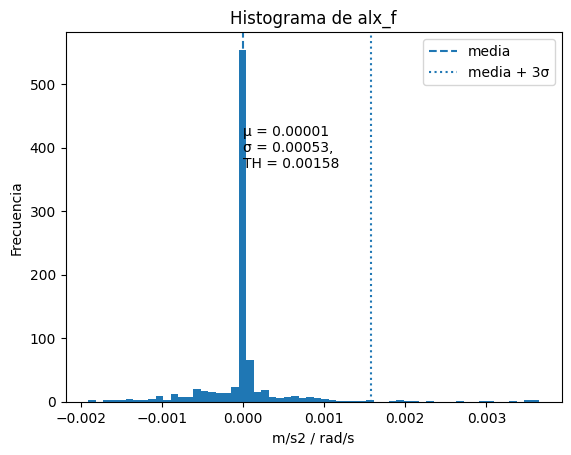

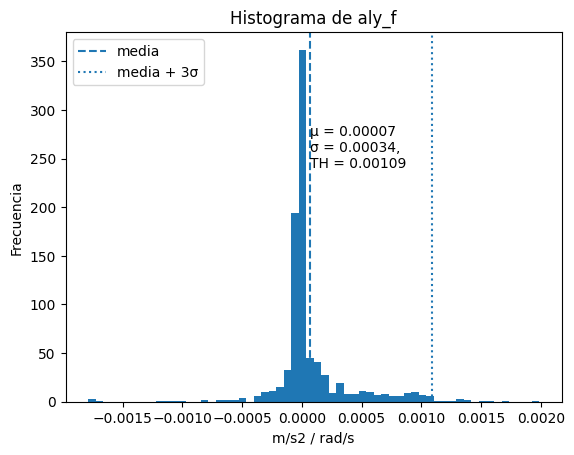

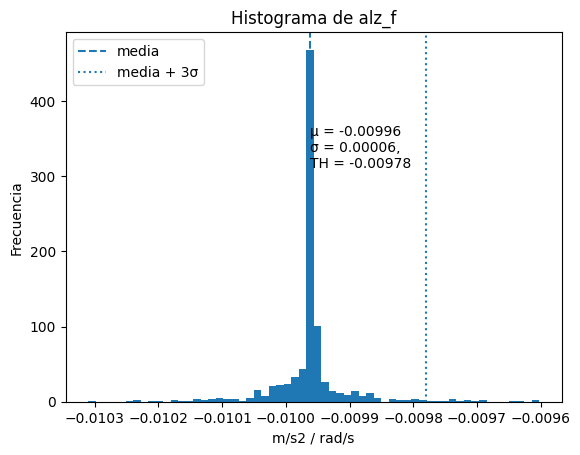

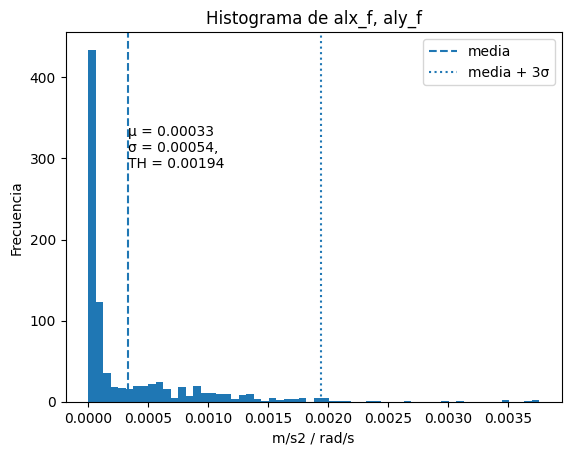

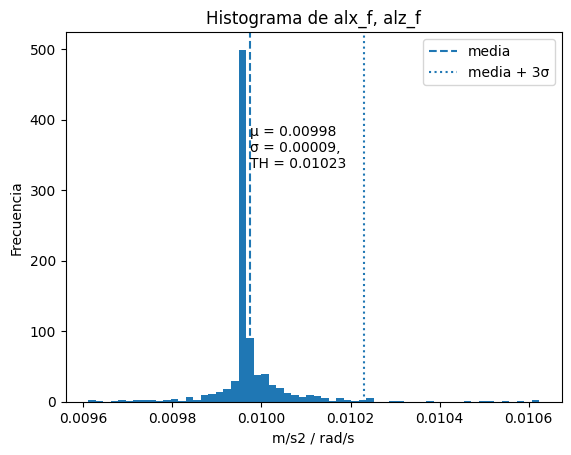

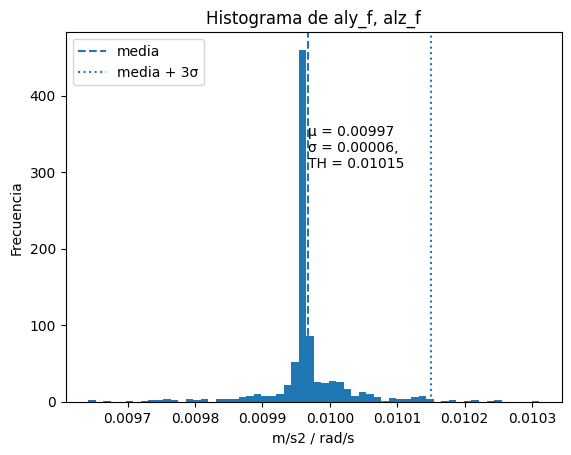

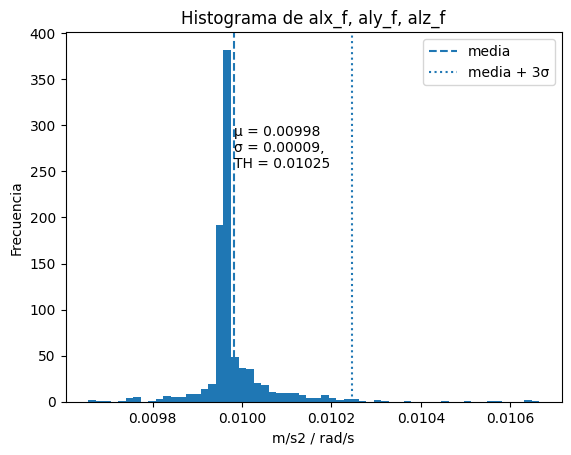

In [176]:
# σ describe ruido + vibración

# segun prueba obtener umbrales y ganancias
import numpy as np
import matplotlib.pyplot as plt

# accl = df_u[["alx_f", "aly_f", "alz_f"]].values#.copy()
# print(accl)
# gyro = df_u[["arx_f", "ary_f", "arz_f"]].values

def histogramaUnEje(axis):
    axis_values = df_u[axis].values
    # axis_values = np.linalg.norm(axis_values)

    axis_mean  = np.mean(axis_values)
    axis_std   = np.std(axis_values)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_values, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis}")
    plt.legend()

    print(f"Threshold {axis}: {th_value}")

def histogramaDosEjes(axis1, axis2):
    axis_values = df_u[[axis1, axis2]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}")
    plt.legend()

    print(f"Threshold norm({axis1},{axis2}): {th_value}")

def histogramaTresEjes(axis1, axis2, axis3):
    axis_values = df_u[[axis1, axis2, axis3]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}, {axis3}")
    plt.legend()
    
    print(f"Threshold norm({axis1},{axis2},{axis3}): {th_value}")

histogramaUnEje("alx_f")
histogramaUnEje("aly_f")
histogramaUnEje("alz_f")
histogramaDosEjes("alx_f", "aly_f")
histogramaDosEjes("alx_f", "alz_f")
histogramaDosEjes("aly_f", "alz_f")
histogramaTresEjes("alx_f", "aly_f", "alz_f")

Threshold arx_f: 0.0027593684014439253
Threshold ary_f: 0.00017244258878565928
Threshold arz_f: 0.015000151303984573
Threshold norm(arx_f,ary_f): 0.0028774532729375765
Threshold norm(arx_f,arz_f): 0.015943206958250963
Threshold norm(ary_f,arz_f): 0.015765080422409563
Threshold norm(arx_f,ary_f,arz_f): 0.015943807308265594


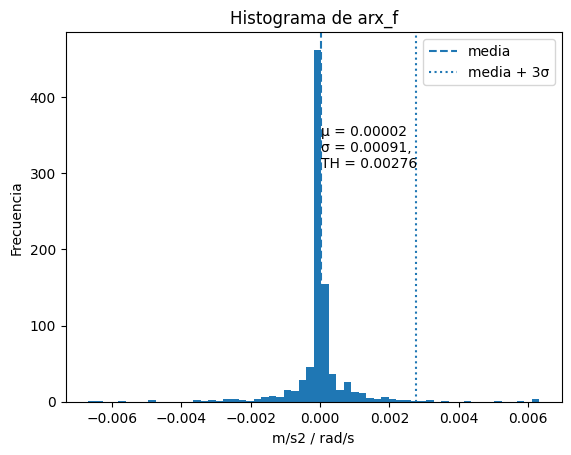

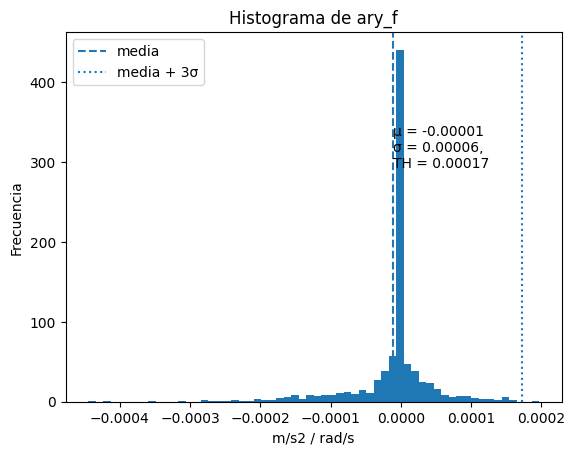

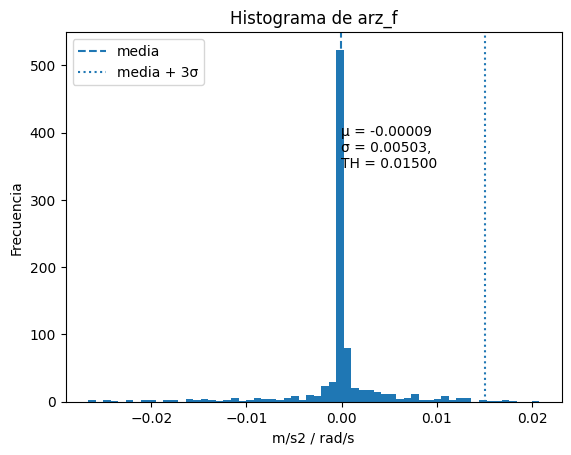

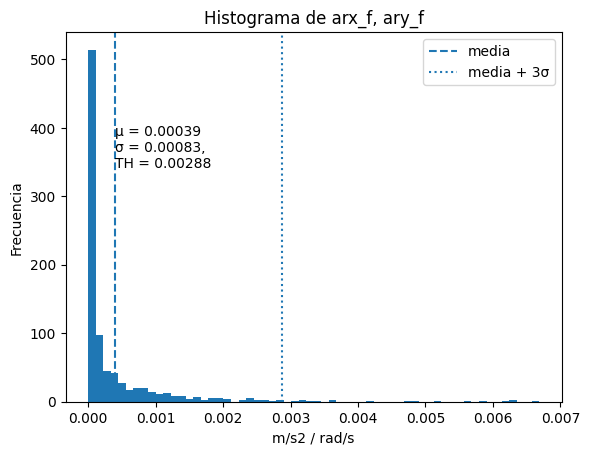

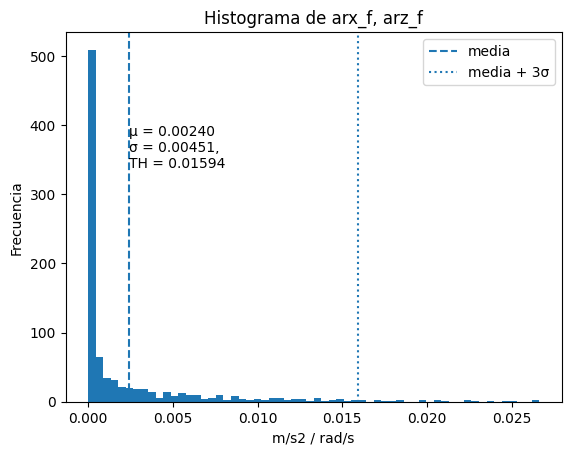

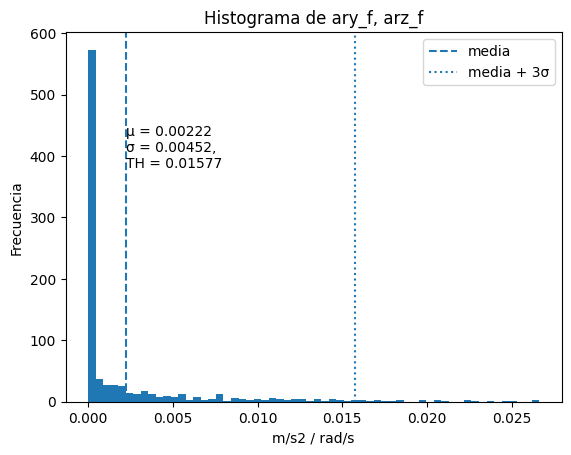

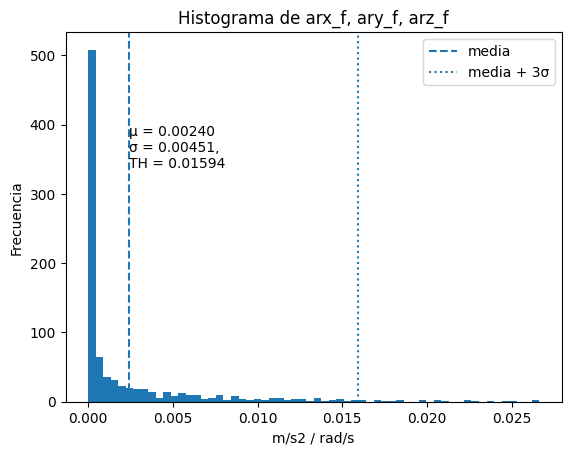

In [177]:
histogramaUnEje("arx_f")
histogramaUnEje("ary_f")
histogramaUnEje("arz_f")
histogramaDosEjes("arx_f", "ary_f")
histogramaDosEjes("arx_f", "arz_f")
histogramaDosEjes("ary_f", "arz_f")
histogramaTresEjes("arx_f", "ary_f", "arz_f")

In [178]:
"""ACC_TH   = 0.15          # m/s²
GYRO_TH  = np.deg2rad(1)

K_zupt   = 0.5
K_nhc_y  = 0.8
K_nhc_z  = 0.9

G_acc    = 0.8
G_gyro   = 1.0"""

'ACC_TH   = 0.15          # m/s²\nGYRO_TH  = np.deg2rad(1)\n\nK_zupt   = 0.5\nK_nhc_y  = 0.8\nK_nhc_z  = 0.9\n\nG_acc    = 0.8\nG_gyro   = 1.0'

In [179]:
# x1 = 2.5
# x0 = 0.5
# x = 1 / (1+((np.e)**-(1*(x-x))))
# x

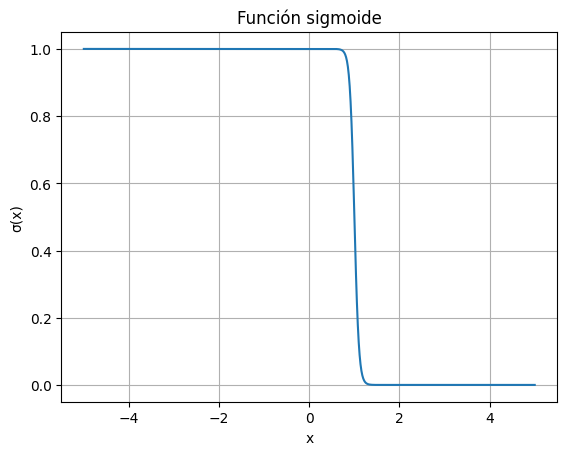

In [180]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    # k = 10 # que tan rápido crece la transición, espacio entre rangos
    # x0 = 0.5 # punto de activación - umbral # control de reposo
    valor_min = 0
    valor_max = 1
    # s = 1 / (1 + np.exp(-k*(x-x0)))
    # z = 1 / (1 + np.exp(k * (x - x0)))
    # z = np.clip(z, 0, 60)  # evita overflow

    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)  # evita overflow
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

x = np.linspace(-5, 5, 1000)
y = sigmoid_k(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

# Criterio de eleccion de ruido
# ACC_TH  ≈ 3σ_acc
# GYRO_TH ≈ 3σ_gyro

In [181]:
pruebinia = sigmoid_k(0.527151, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=10.0)
pruebinia

np.float64(0.9912376484362222)

In [182]:
y = 1 / (1+((np.e)**-2.5))
y

0.9241418199787566

In [183]:
# G_acc ≈ 1.0 en recta

# G_acc ≈ 0.7 si vibra mucho

# G_acc ≈ 0.3 si hay mucho ruido

In [184]:
# from scipy.spatial.transform import Rotation as R

# def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
#     valor_min = 0
#     valor_max = 1
#     z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
#     z = np.clip(z, -10, 10)
#     z = 1 / (1 + np.exp(z))
#     return valor_min + (valor_max - valor_min) * z

#     """ 
#     G_acc = 0.8   # 1 = full confianza
#     G_gyro = 1.0

#     # Umbrales de ZUPT
#     ACC_TH = 0.269
#     GYRO_TH = 0.0172

#     K_zupt = 0.5

#     # # restricciones vehículo
#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical
#     """

# def ins(df=df_u,
#         G_acc=1.0,
#         G_gyro=1.0,
#         p_gain=1.0,
#         ACC_TH=0.0732, # ACC_TH=0.269,
#         GYRO_TH=0.0112, # GYRO_TH=0.0172,
#         ZUPT_GAIN=0.5,
#         ZUPT_X0=1.0,
#         ZUPT_SIGMOID_GAIN=1.0,
#         K_nhc_y=0.9,
#         K_nhc_z=0.9,
#         dt = 0.01):

#     p = np.zeros(3)
#     p_scale = np.zeros(3)
#     v = np.zeros(3)
#     v_body = np.zeros(3)

#     for k in range(0, len(df)):

#         if pd.isna(dt):
#             continue

#         a_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
#         g = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#         gyro_gain = np.linalg.norm(G_gyro * g)

#         q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
#         # 1) Normalizar cuaternión
#         q = q / np.linalg.norm(q)

#         # 2) Rotación body → inercial
#         r = R.from_quat([q[1], q[2], q[3], q[0]])
#         R_nb = r.as_matrix().T   # body → nav

#         # 3) Aceleración en marco inercial
#         a_nav = G_acc * (R_nb @ a_body)

#         df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#         # Velocidad
#         v = v + a_nav * dt

#         v = v + R_nb @ delta_v + g_nav * dt # g_nav ¿

#         df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#         acc_norm  = np.linalg.norm(a_body)
#         gyro_norm = np.linalg.norm(gyro_gain)

#         s_acc  = acc_norm  / ACC_TH
#         s_gyro = gyro_norm / GYRO_TH

#         zupt_score = max(s_acc, s_gyro)

#         df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

#         # w_zupt = smooth_step(zupt_score)
#         w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
#         # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#         v -= ZUPT_GAIN * w_zupt * v

#         # velocidad en body frame
#         v_body = R_nb.T @ v

#         v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#         v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

#         df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

#         # volver a nav
#         v = R_nb @ v_body

#         # Posición
#         p = p + v * dt

#         df.loc[k, ["vx", "vy", "vz"]] = v
#         df.loc[k, ["px", "py", "pz"]] = p
#         df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
#     print(df)
#     # df_u

In [185]:
# ins()

In [186]:
# import numpy as np
# import pandas as pd

# ###############################################
# # Utilidades matemáticas
# ###############################################

# def skew(v):
#     """Matriz skew-symmetric"""
#     return np.array([
#         [0, -v[2], v[1]],
#         [v[2], 0, -v[0]],
#         [-v[1], v[0], 0]
#     ])

# def quat_normalize(q):
#     return q / np.linalg.norm(q)

# def quat_multiply(q1, q2):
#     """Multiplicación de cuaterniones"""
#     w1,x1,y1,z1 = q1
#     w2,x2,y2,z2 = q2

#     return np.array([
#         w1*w2 - x1*x2 - y1*y2 - z1*z2,
#         w1*x2 + x1*w2 + y1*z2 - z1*y2,
#         w1*y2 - x1*z2 + y1*w2 + z1*x2,
#         w1*z2 + x1*y2 - y1*x2 + z1*w2
#     ])

# def quat_to_rot(q):
#     """Cuaternión → matriz de rotación"""
#     w,x,y,z = q

#     return np.array([
#         [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
#         [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
#         [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
#     ])

# ###############################################
# # Incremental quaternion
# ###############################################

# def delta_theta_to_quat(dtheta):
#     theta = np.linalg.norm(dtheta)

#     if theta < 1e-12:
#         return np.array([1,0,0,0])

#     axis = dtheta/theta

#     w = np.cos(theta/2)
#     xyz = axis*np.sin(theta/2)

#     return np.array([w, xyz[0], xyz[1], xyz[2]])

# ###############################################
# # Coning correction
# ###############################################

# def coning(dtheta1, dtheta2):
#     return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

# ###############################################
# # Sculling correction
# ###############################################

# def sculling(dtheta1, dtheta2, dv1, dv2):

#     term = 0.5*(np.cross(dtheta1,dv2) +
#                 np.cross(dv1,dtheta2))

#     return dv1 + dv2 + term

# ###############################################
# # ZUPT detector simple
# ###############################################

# def zupt_detector(acc_norm, gyro_norm,
#                   acc_th=0.2, gyro_th=0.02):

#     if acc_norm < acc_th and gyro_norm < gyro_th:
#         return True

#     return False

# ###############################################
# # Clase INS Strapdown
# ###############################################

# class StrapdownINS:

#     def __init__(self, dt):

#         self.dt = dt

#         # estado
#         self.q = np.array([1,0,0,0])
#         self.v = np.zeros(3)
#         self.p = np.zeros(3)

#         # gravedad
#         self.g = np.array([0,0,-9.81])

#         # buffers para coning/sculling
#         self.prev_dtheta = np.zeros(3)
#         self.prev_dv = np.zeros(3)

#     ###########################################

#     def step(self, dtheta, dv):

#         dt = self.dt

#         ###################################
#         # 1 Coning correction
#         ###################################

#         dtheta_c = coning(self.prev_dtheta, dtheta)

#         ###################################
#         # 2 Actualizar actitud
#         ###################################

#         dq = delta_theta_to_quat(dtheta_c)

#         self.q = quat_multiply(self.q, dq)
#         self.q = quat_normalize(self.q)

#         R_nb = quat_to_rot(self.q)

#         ###################################
#         # 3 Sculling correction
#         ###################################

#         dv_c = sculling(self.prev_dtheta,
#                         dtheta,
#                         self.prev_dv,
#                         dv)

#         ###################################
#         # 4 Transformar a nav
#         ###################################

#         dv_nav = R_nb @ dv_c

#         ###################################
#         # 5 Velocidad
#         ###################################

#         self.v = self.v + dv_nav + self.g*dt

#         ###################################
#         # 6 Posición
#         ###################################

#         self.p = self.p + self.v*dt + 0.5*dv_nav

#         ###################################
#         # Guardar para siguiente paso
#         ###################################

#         self.prev_dtheta = dtheta
#         self.prev_dv = dv

#         return self.q, self.v, self.p


# ###############################################
# # Ejecución sobre dataframe
# ###############################################

# def run_ins(df, dt):

#     ins = StrapdownINS(dt)

#     q_log = []
#     v_log = []
#     p_log = []

#     for k in range(len(df)):

#         dtheta = df.loc[k, ["dthx","dthy","dthz"]].values
#         dv = df.loc[k, ["dvx","dvy","dvz"]].values

#         q,v,p = ins.step(dtheta, dv)

#         ###################################
#         # ZUPT
#         ###################################

#         acc_norm = np.linalg.norm(dv)/dt
#         gyro_norm = np.linalg.norm(dtheta)/dt

#         if zupt_detector(acc_norm, gyro_norm):

#             v *= 0.0

#         ###################################

#         q_log.append(q)
#         v_log.append(v.copy())
#         p_log.append(p.copy())

#     q_log = np.array(q_log)
#     v_log = np.array(v_log)
#     p_log = np.array(p_log)

#     df["qx"] = q_log[:,1]
#     df["qy"] = q_log[:,2]
#     df["qz"] = q_log[:,3]
#     df["qw"] = q_log[:,0]

#     df["vx"] = v_log[:,0]
#     df["vy"] = v_log[:,1]
#     df["vz"] = v_log[:,2]

#     df["px"] = p_log[:,0]
#     df["py"] = p_log[:,1]
#     df["pz"] = p_log[:,2]

#     return df


# if __name__ == "__main__":

#     dt = 0.01

#     N = 1000

#     data = {
#         "dthx": np.random.normal(0,1e-4,N),
#         "dthy": np.random.normal(0,1e-4,N),
#         "dthz": np.random.normal(0,1e-4,N),

#         "dvx": np.random.normal(0,1e-3,N),
#         "dvy": np.random.normal(0,1e-3,N),
#         "dvz": np.random.normal(0,1e-3,N)
#     }

#     df = pd.DataFrame(data)

#     df = run_ins(df, dt)

#     print(df[["px","py","pz"]].tail())

In [187]:
from scipy.spatial.transform import Rotation as R

###############################################
# Coning correction
###############################################

def coning(dtheta1, dtheta2):
    return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

###############################################
# Sculling correction
###############################################

def sculling(dtheta1, dtheta2, dv1, dv2):

    term = 0.5*(np.cross(dtheta1,dv2) +
                np.cross(dv1,dtheta2))

    return dv1 + dv2 + term

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    valor_min = 0
    valor_max = 1
    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

def ins(df=df_u,
        G_acc=1.0,
        G_gyro=1.0,
        p_gain=1.0,
        ACC_TH=0.02, # ACC_TH=0.269,
        GYRO_TH=0.02, # GYRO_TH=0.0172,
        ZUPT_GAIN=0.5,
        ZUPT_X0=1.0,
        ZUPT_SIGMOID_GAIN=10.0,
        K_nhc_y=0.9,
        K_nhc_z=0.9,
        dt = 0.01):

    # estado
    q = np.array([1,0,0,0])
    v = np.zeros(3)
    p = np.zeros(3)

    # gravedad
    g_nav = np.array([0,0,-9.81])
    g = 0.00996
    
    v_prev = np.zeros(3)

    p_scale = np.zeros(3)
    
    
    v_body = np.zeros(3)
    dv_body = np.zeros(3)

    # buffers para coning/sculling
    prev_dtheta = np.zeros(3)
    prev_dv = np.zeros(3)

    for k in range(0, len(df)):

        if pd.isna(dt):
            continue

        dv_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
        dtheta = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

        # gyro_gain = np.linalg.norm(G_gyro * g)

        q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
        # 1) Normalizar cuaternión
        q = q / np.linalg.norm(q)

        # 2) Rotación body → inercial
        r = R.from_quat([q[1], q[2], q[3], q[0]])
        R_nb = r.as_matrix().T   # body → nav

        dv_c = sculling(prev_dtheta, dtheta, prev_dv, dv_body)
        prev_dtheta = dtheta
        prev_dv = dv_body

        # 3) Aceleración en marco inercial
        dv_nav = R_nb @ dv_c # dv_body # a_nav = G_acc * (R_nb @ a_body)

        df.loc[k, ["dv_nav_x", "dv_nav_y", "dv_nav_z"]] = dv_nav 
        df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = dv_nav

        # Velocidad
        v = v + dv_nav + g_nav * dt # v = v + a_nav * dt

        df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        dv_body_xy = [dv_body[0], dv_body[1]]

        acc_norm  = np.linalg.norm(dv_body_xy)/dt
        gyro_norm = np.linalg.norm(dtheta)/dt

        s_acc  = acc_norm  / ACC_TH
        s_gyro = gyro_norm / GYRO_TH

        # zupt_score = max(s_acc, s_gyro)
        zupt_score = np.sqrt(s_acc**2 + s_gyro**2)

        df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

        # w_zupt = smooth_step(zupt_score)
        w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
        # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

        v -= ZUPT_GAIN * w_zupt * v

        # velocidad en body frame
        v_body = R_nb.T @ v

        v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
        v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)

        df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

        # volver a nav
        v_new = R_nb @ v_body

        # Posición
        p = p + 0.5 * (v + v_new) * dt

        v = v_new

        p_scale = p_gain * p

        df.loc[k, ["vx", "vy", "vz"]] = v
        df.loc[k, ["px", "py", "pz"]] = p
        df.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale
        
    print(df)
    # df_u

In [188]:
ins()

                    time        q0        q1        q2        q3       arx  \
0    1773426542826902016  0.999262  0.004135  0.000660  0.038173  0.000009   
1    1773426542836676608  0.999262  0.004132  0.000662  0.038171 -0.000007   
2    1773426542846929408  0.999263  0.004135  0.000663  0.038166  0.000005   
3    1773426542867624192  0.999263  0.004135  0.000661  0.038163 -0.000002   
4    1773426542877822976  0.999263  0.004134  0.000662  0.038160 -0.000003   
..                   ...       ...       ...       ...       ...       ...   
895  1773426557861971456  0.999678  0.004148  0.000018  0.025045 -0.000030   
896  1773426557891943168  0.999678  0.004145  0.000023  0.025027  0.000007   
897  1773426557901742592  0.999678  0.004155  0.000025  0.025023  0.000021   
898  1773426557941829120  0.999678  0.004216  0.000021  0.025004  0.000039   
899  1773426557951974400  0.999678  0.004240  0.000017  0.025000  0.000048   

              ary           arz       alx       aly  ...   v_nh

In [189]:
# import numpy as np
# import pandas as pd

# ###############################################
# # Utilidades matemáticas
# ###############################################

# def skew(v):
#     """Matriz skew-symmetric"""
#     return np.array([
#         [0, -v[2], v[1]],
#         [v[2], 0, -v[0]],
#         [-v[1], v[0], 0]
#     ])

# def quat_normalize(q):
#     return q / np.linalg.norm(q)

# def quat_multiply(q1, q2):
#     """Multiplicación de cuaterniones"""
#     w1,x1,y1,z1 = q1
#     w2,x2,y2,z2 = q2

#     return np.array([
#         w1*w2 - x1*x2 - y1*y2 - z1*z2,
#         w1*x2 + x1*w2 + y1*z2 - z1*y2,
#         w1*y2 - x1*z2 + y1*w2 + z1*x2,
#         w1*z2 + x1*y2 - y1*x2 + z1*w2
#     ])

# def quat_to_rot(q):
#     """Cuaternión → matriz de rotación"""
#     w,x,y,z = q

#     return np.array([
#         [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
#         [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
#         [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
#     ])

# ###############################################
# # Incremental quaternion
# ###############################################

# def delta_theta_to_quat(dtheta):
#     theta = np.linalg.norm(dtheta)

#     if theta < 1e-12:
#         return np.array([1,0,0,0])

#     axis = dtheta/theta

#     w = np.cos(theta/2)
#     xyz = axis*np.sin(theta/2)

#     return np.array([w, xyz[0], xyz[1], xyz[2]])

# ###############################################
# # Coning correction
# ###############################################

# def coning(dtheta1, dtheta2):
#     return dtheta1 + dtheta2 + 0.5*np.cross(dtheta1,dtheta2)

# ###############################################
# # Sculling correction
# ###############################################

# def sculling(dtheta1, dtheta2, dv1, dv2):

#     term = 0.5*(np.cross(dtheta1,dv2) +
#                 np.cross(dv1,dtheta2))

#     return dv1 + dv2 + term

# ###############################################
# # ZUPT detector simple
# ###############################################

# def zupt_detector(acc_norm, gyro_norm,
#                   acc_th=0.2, gyro_th=0.02):

#     if acc_norm < acc_th and gyro_norm < gyro_th:
#         return True

#     return False

# ###############################################
# # Clase INS Strapdown
# ###############################################

# class StrapdownINS:

#     def __init__(self, dt):

#         self.dt = dt

#         # estado
#         self.q = np.array([1,0,0,0])
#         self.v = np.zeros(3)
#         self.p = np.zeros(3)

#         # gravedad
#         self.g = np.array([0,0,-9.81])

#         # buffers para coning/sculling
#         self.prev_dtheta = np.zeros(3)
#         self.prev_dv = np.zeros(3)

#     ###########################################

#     def step(self, dtheta, dv):

#         dt = self.dt

#         ###################################
#         # 1 Coning correction
#         ###################################

#         dtheta_c = coning(self.prev_dtheta, dtheta)

#         ###################################
#         # 2 Actualizar actitud
#         ###################################

#         dq = delta_theta_to_quat(dtheta_c)

#         self.q = quat_multiply(self.q, dq)
#         self.q = quat_normalize(self.q)

#         R_nb = quat_to_rot(self.q)

#         ###################################
#         # 3 Sculling correction
#         ###################################

#         dv_c = sculling(self.prev_dtheta,
#                         dtheta,
#                         self.prev_dv,
#                         dv)

#         ###################################
#         # 4 Transformar a nav
#         ###################################

#         dv_nav = R_nb @ dv_c

#         ###################################
#         # 5 Velocidad
#         ###################################

#         self.v = self.v + dv_nav + self.g*dt

#         ###################################
#         # 6 Posición
#         ###################################

#         self.p = self.p + self.v*dt + 0.5*dv_nav

#         ###################################
#         # Guardar para siguiente paso
#         ###################################

#         self.prev_dtheta = dtheta
#         self.prev_dv = dv

#         return self.q, self.v, self.p


# ###############################################
# # Ejecución sobre dataframe
# ###############################################

# def run_ins(df, dt):

#     ins = StrapdownINS(dt)

#     q_log = []
#     v_log = []
#     p_log = []

#     for k in range(len(df)):

#         dtheta = df.loc[k, ["dthx","dthy","dthz"]].values
#         dv = df.loc[k, ["dvx","dvy","dvz"]].values

#         q,v,p = ins.step(dtheta, dv)

#         ###################################
#         # ZUPT
#         ###################################

#         acc_norm = np.linalg.norm(dv)/dt
#         gyro_norm = np.linalg.norm(dtheta)/dt

#         if zupt_detector(acc_norm, gyro_norm):

#             v *= 0.0

#         ###################################

#         q_log.append(q)
#         v_log.append(v.copy())
#         p_log.append(p.copy())

#     q_log = np.array(q_log)
#     v_log = np.array(v_log)
#     p_log = np.array(p_log)

#     df["qx"] = q_log[:,1]
#     df["qy"] = q_log[:,2]
#     df["qz"] = q_log[:,3]
#     df["qw"] = q_log[:,0]

#     df["vx"] = v_log[:,0]
#     df["vy"] = v_log[:,1]
#     df["vz"] = v_log[:,2]

#     df["px"] = p_log[:,0]
#     df["py"] = p_log[:,1]
#     df["pz"] = p_log[:,2]

#     return df


# if __name__ == "__main__":

#     dt = 0.01

#     N = 1000

#     data = {
#         "dthx": np.random.normal(0,1e-4,N),
#         "dthy": np.random.normal(0,1e-4,N),
#         "dthz": np.random.normal(0,1e-4,N),

#         "dvx": np.random.normal(0,1e-3,N),
#         "dvy": np.random.normal(0,1e-3,N),
#         "dvz": np.random.normal(0,1e-3,N)
#     }

#     df = pd.DataFrame(data)

#     df = run_ins(df, dt)

#     print(df[["px","py","pz"]].tail())

In [190]:
# from scipy.spatial.transform import Rotation as R

# p = np.zeros(3)
# v = np.zeros(3)
# v_body = np.zeros(3)

# # def smooth_step(x, x0=1.0, k=10.0):
# #     return 1.0 / (1.0 + np.exp(k*(x - x0)))

# for k in range(0, len(df_u)):

#     # dt = df_a.loc[k, "dt"]
#     dt = 0.01

#     # Si el primer dt es NaN, lo saltamos
#     if pd.isna(dt):
#         continue

#     a_body = df_u.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()

#     G_acc = 0.8   # 1 = full confianza

#     g = df_u.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#     G_gyro = 1.0
#     # a_body[1:] = 0

#     gyro_gain = np.linalg.norm(G_gyro * g)

#     q = df_u.loc[k, ["q0", "q1", "q2", "q3"]].values

#     # 1) Normalizar cuaternión (seguridad numérica)
#     q = q / np.linalg.norm(q)

#     # 2) Rotación body → inercial (pasiva)
#     r = R.from_quat([q[1], q[2], q[3], q[0]])
#     R_nb = r.as_matrix().T   # body → nav

#     # 3) Aceleración en marco inercial
#     a_nav = G_acc * (R_nb @ a_body)

#     df_u.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#     # Velocidad
#     v = v + a_nav * dt

#     df_u.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#     # Detección ZUPT
#     # vk+1 ​= vk ​− Kzupt​ * vk​
#     # Caso A
#     # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:

#     # Umbrales // se obtienen de prueba en estático // evaluar si se obtiene en calibracion
#     ACC_TH = 0.269       # m/s^2
#     # GYRO_TH = np.deg2rad(0.7)  # 0.012 rad/s
#     GYRO_TH = 0.0172  # rad/s / obtenido de estaod en reposo


#     acc_norm  = np.linalg.norm(a_body)
#     gyro_norm = np.linalg.norm(gyro_gain)

#     s_acc  = acc_norm  / ACC_TH
#     s_gyro = gyro_norm / GYRO_TH

#     zupt_score = max(s_acc, s_gyro)
#     # zupt_score = max(acc_norm, gyro_norm)

#     df_u.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score
#     # if acc_norm < ACC_TH and gyro_norm < GYRO_TH:
#     #     # v = np.zeros(3)   # ZUPT duro
#     #     v_body[:] = 0.0

#     K_zupt = 0.5   # ganancia ZUPT (tunable)

#     # w_zupt = smooth_step(zupt_score)
#     w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#     v -= K_zupt * w_zupt * v
    
#     # df_u.loc[k, ["v_zupt_x", "v_zupt_y", "v_zupt_z"]] = v_zupt

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # else:
#     # NHC suave

#     # K_nhc_y = 0.8   # lateral
#     # K_nhc_z = 0.9   # vertical

#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # # restricciones vehículo
#     # v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#     # v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)
#     # # v_body[1:] = 0.0

#     v_body[1] = K_nhc_y * v_body[1]   # no deslizamiento lateral
#     v_body[2] = K_nhc_z * v_body[2]   # no salto vertical (opcional)

#     # volver a nav
#     v = R_nb @ v_body

#     # Posición
#     p = p + v * dt

#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)


#     # zupt = (np.linalg.norm(a_body) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

#     # if zupt:
#     #     # eje principal de movimiento
#     #     v[1] = 0.0   # Y duro

#     #     # ejes no excitados → corrección más agresiva
#     #     if abs(v[0]) < 0.02:
#     #         v[0] = 0.0
#     #     if abs(v[2]) < 0.02:
#     #         v[2] = 0.0

#     # E = np.mean(np.sum(a_window**2, axis=1))
#     # if E < ACC_TH_ENERGY:
#     #     v = np.zeros(3)

#     # Guardar en el DataFrame
#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
#     df_u.loc[k, ["vx", "vy", "vz"]] = v
#     df_u.loc[k, ["px", "py", "pz"]] = p
    
# # print(df_u)
# df_u

In [191]:
N = df_u.shape[0]
t = np.arange(N) / fs

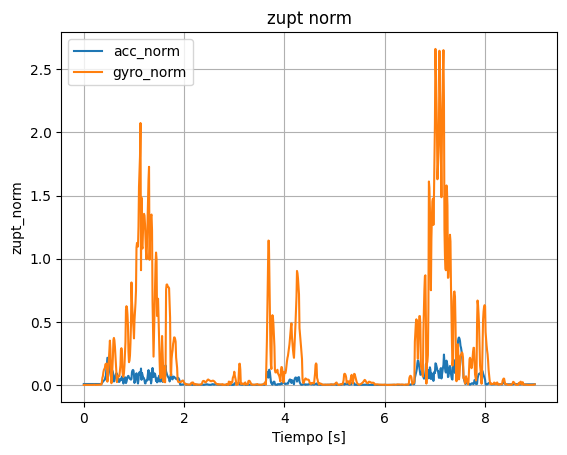

In [192]:
plt.figure()
plt.plot(t, df_u["acc_norm"], label="acc_norm")
plt.plot(t, df_u["gyro_norm"], label="gyro_norm")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_norm")
plt.legend()
plt.grid(True)
plt.title("zupt norm")
plt.show()

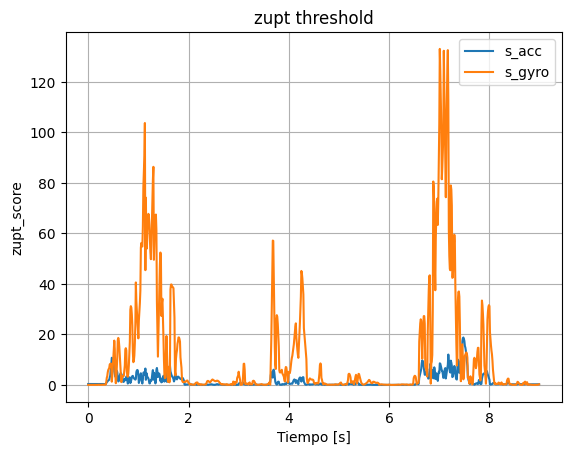

In [193]:
plt.figure()
plt.plot(t, df_u["s_acc"], label="s_acc")
plt.plot(t, df_u["s_gyro"], label="s_gyro")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_score")
plt.legend()
plt.grid(True)
plt.title("zupt threshold")
plt.show()

In [194]:
"""# 1. ZUPT DURO
if ||a|| < ACC_TH and ||ω|| < GYRO_TH:
    v = 0

# 2. ZUPT como realimentación
vk+1​ = vk ​− Kzupt​ vk​

# 3. Detector zupT continuo (sin umbral duro)
# 3.1 Metrica de reposo (score)
acc_norm  = np.linalg.norm(a_body)
gyro_norm = np.linalg.norm(g)

s_acc  = acc_norm  / ACC_TH
s_gyro = gyro_norm / GYRO_TH

zupt_score = max(s_acc, s_gyro)

# 3.2 Activacion suave (funcion logistica)
def smooth_step(x, x0=1.0, k=10.0):
    return 1.0 / (1.0 + np.exp(k*(x - x0)))

w_zupt = smooth_step(zupt_score) 
# w_zupt = 1 -> ZUPT fuerte
# w_zupt = 0 -> sin ZUPT

# 4 ZUPT suave con ganancia
K_zupt = 0.5 # ganancia ZUPT (tuneable)

v -= K_zupt * w_zupt * v

# 5 HNC suave (no holonómica bien hecha)
# 5.1 Pasar velocidad a body
v_body = R_nb.T @ v"""

'# 1. ZUPT DURO\nif ||a|| < ACC_TH and ||ω|| < GYRO_TH:\n    v = 0\n\n# 2. ZUPT como realimentación\nvk+1\u200b = vk \u200b− Kzupt\u200b vk\u200b\n\n# 3. Detector zupT continuo (sin umbral duro)\n# 3.1 Metrica de reposo (score)\nacc_norm  = np.linalg.norm(a_body)\ngyro_norm = np.linalg.norm(g)\n\ns_acc  = acc_norm  / ACC_TH\ns_gyro = gyro_norm / GYRO_TH\n\nzupt_score = max(s_acc, s_gyro)\n\n# 3.2 Activacion suave (funcion logistica)\ndef smooth_step(x, x0=1.0, k=10.0):\n    return 1.0 / (1.0 + np.exp(k*(x - x0)))\n\nw_zupt = smooth_step(zupt_score) \n# w_zupt = 1 -> ZUPT fuerte\n# w_zupt = 0 -> sin ZUPT\n\n# 4 ZUPT suave con ganancia\nK_zupt = 0.5 # ganancia ZUPT (tuneable)\n\nv -= K_zupt * w_zupt * v\n\n# 5 HNC suave (no holonómica bien hecha)\n# 5.1 Pasar velocidad a body\nv_body = R_nb.T @ v'

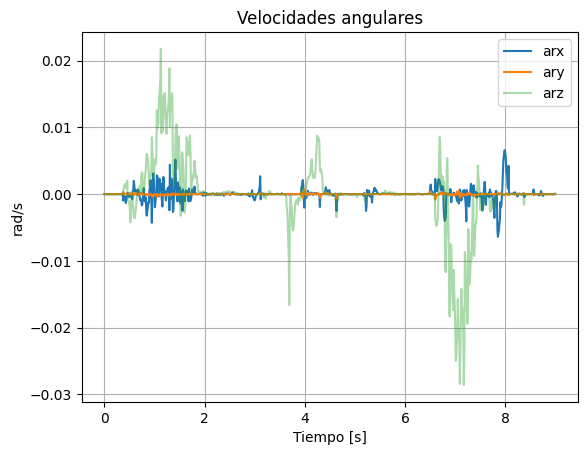

array([-1.29319223e-06,  1.46741296e-07,  1.20801593e-06, ...,
        4.16928297e-05,  4.59631562e-05,  4.99112571e-05], shape=(1499,))

In [195]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

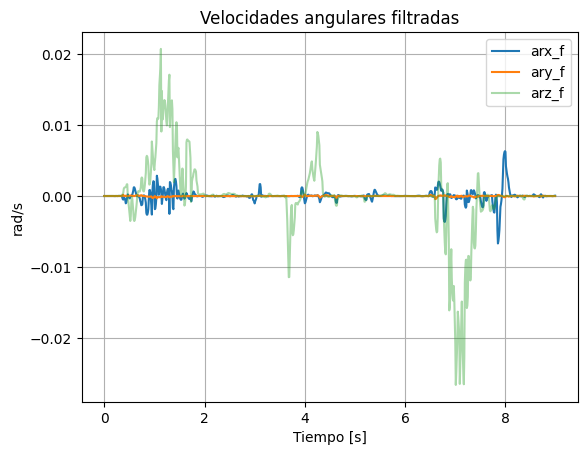

In [196]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

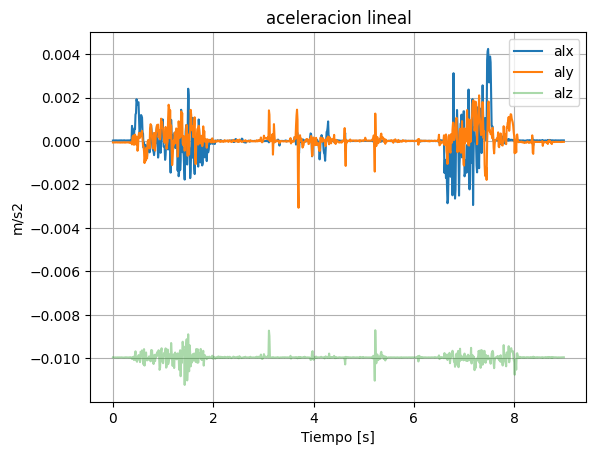

In [197]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

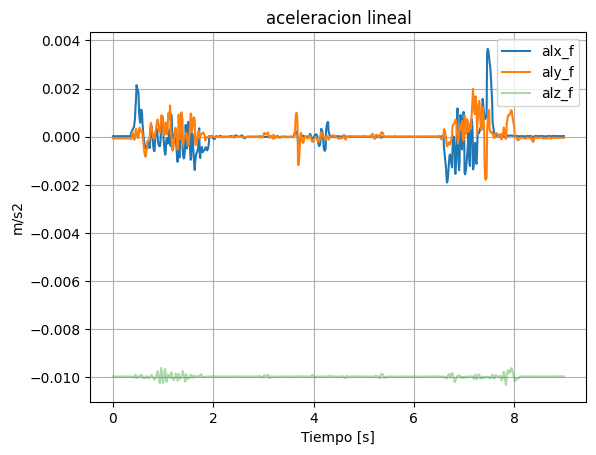

In [198]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

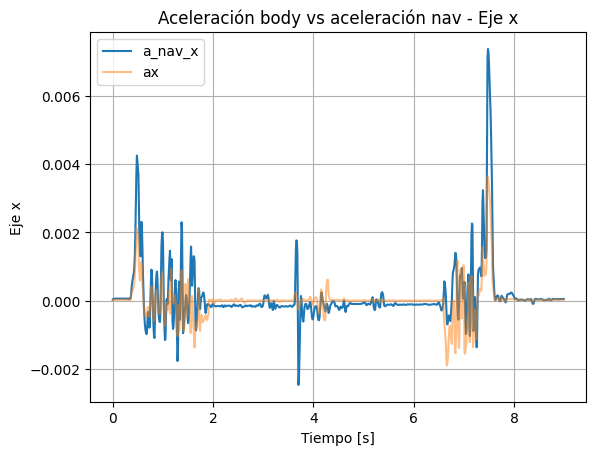

In [199]:
axi = "x"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

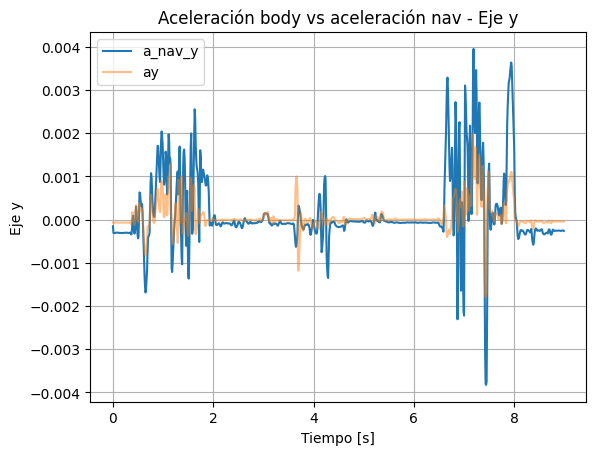

In [200]:
axi = "y"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

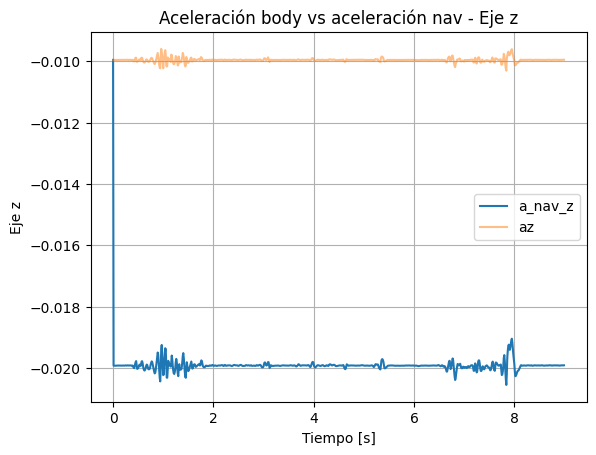

In [201]:
axi = "z"

plt.figure()

plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}")
plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}", alpha=0.5)
# plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
# plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
plt.xlabel("Tiempo [s]")
plt.ylabel(f"Eje {axi}")
plt.legend()
plt.grid(True)
plt.title(f"Aceleración body vs aceleración nav - Eje {axi}")
plt.show()

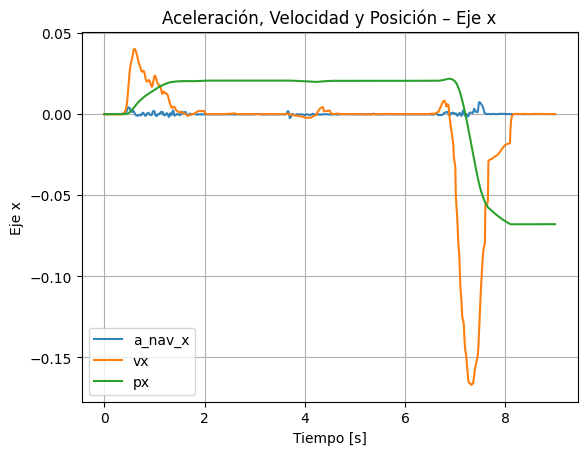

In [202]:
def plot_unEje_ac_v_p(axi):
    plt.figure()

    plt.plot(t, df_u[f"a_nav_{axi}"], label=f"a_nav_{axi}", alpha=0.9)
    # plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

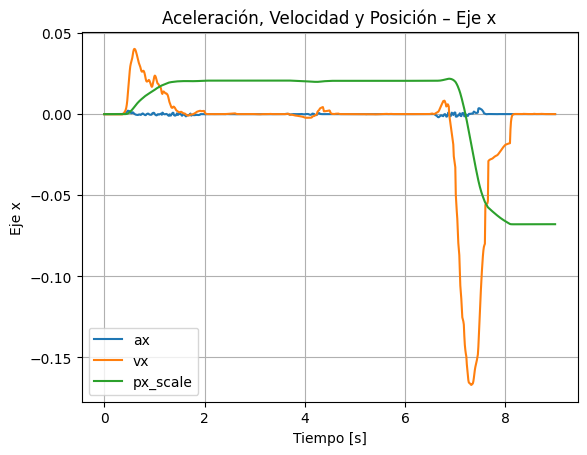

In [203]:
def plot_unEje_ac_v_p(axi):
    plt.figure()
    plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}_scale"], label=f"p{axi}_scale")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

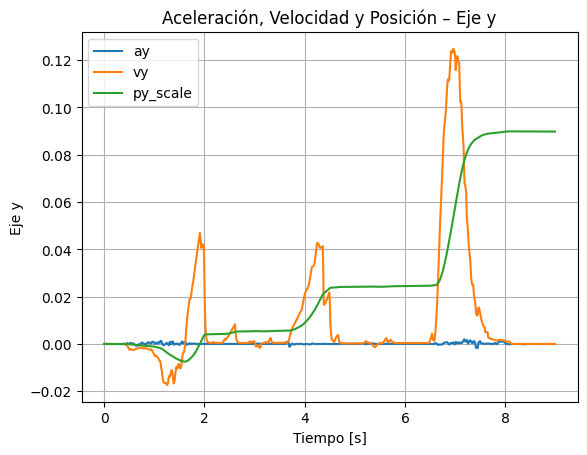

In [204]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("y")

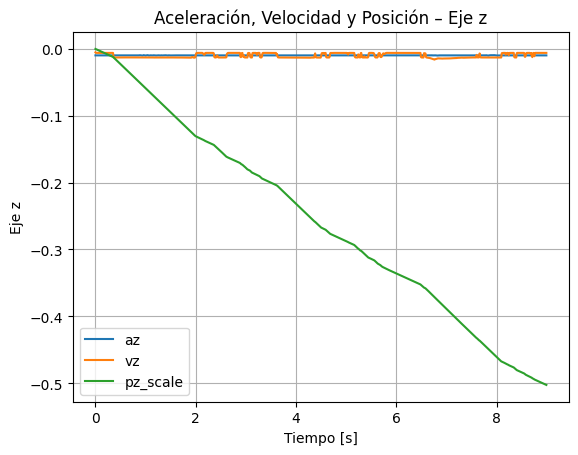

In [205]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("z")

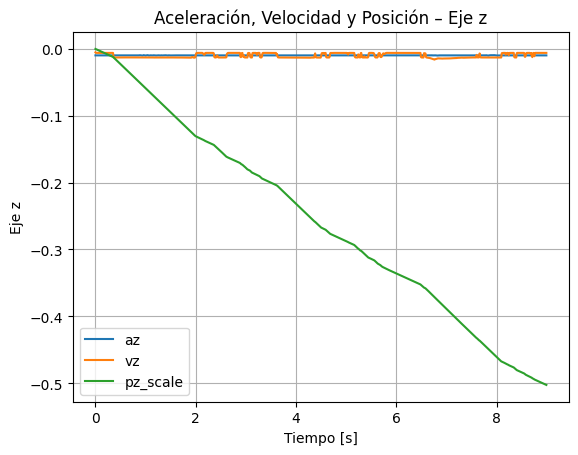

In [206]:
# plt.figure()
# plt.plot(t, df_u["alz_f"], label="az")
# plt.plot(t, df_u["vz"], label="vz")
# plt.plot(t, df_u["pz"], label="pz")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Z")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Z")
# plt.show()

plot_unEje_ac_v_p("z")

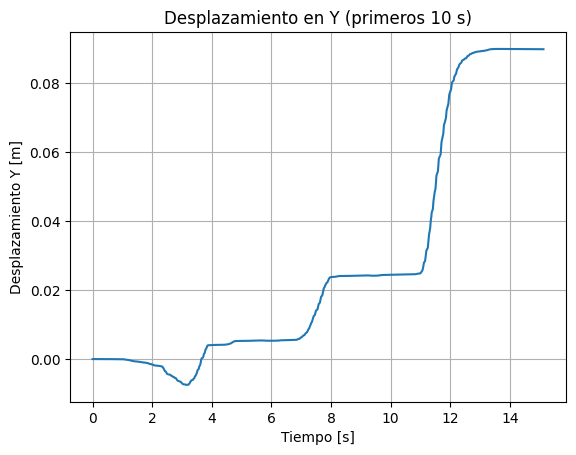

In [207]:
df_u["time_s"] = (df_u["time"] - df_u["time"].iloc[0]) * 1e-9
df_10s = df_u[df_u["time_s"] <= 300]
plt.figure()
plt.plot(df_10s["time_s"], df_10s["py_scale"])
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento Y [m]")
plt.title("Desplazamiento en Y (primeros 10 s)")
plt.grid(True)
plt.show()

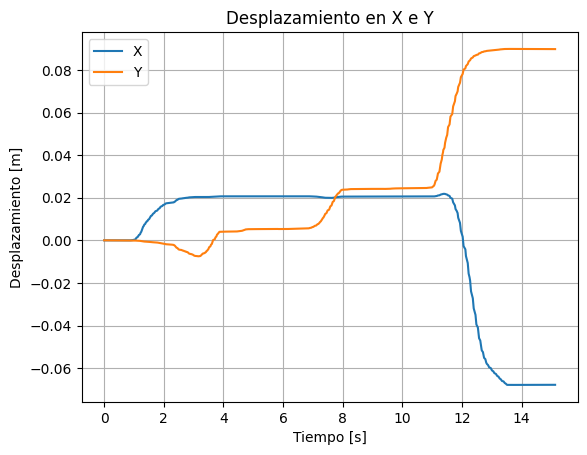

In [208]:
plt.figure()
plt.plot(df_10s["time_s"], df_10s["px_scale"], label="X")
plt.plot(df_10s["time_s"], df_10s["py_scale"], label="Y")

plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.title("Desplazamiento en X e Y")
plt.legend()
plt.grid(True)
plt.show()

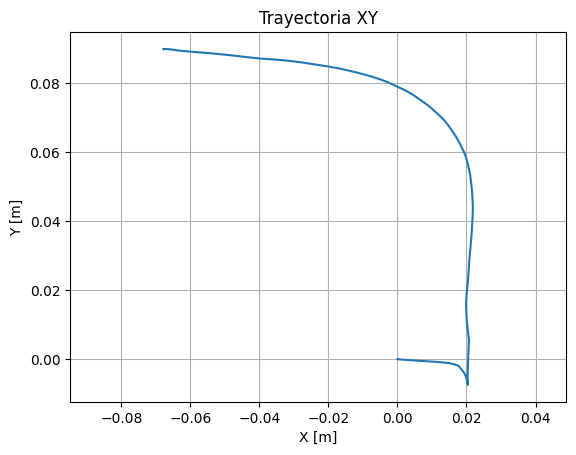

In [209]:
plt.figure()
plt.plot(df_10s["px_scale"], df_10s["py_scale"])
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trayectoria XY")
plt.axis("equal")  # Importante para INS
plt.grid(True)
plt.show()

In [210]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[ 2.18922287e-05 -6.87803404e-05 -9.95822437e-03]
0.0099584859607062
[ 0.00219835 -0.00690671 -0.99997373]
2.189222868764773e-05 2.189222868764773e-05


In [211]:
def plot_unEje(df, axi, params, save_path):

    plt.figure()
    plt.plot(t, df[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df[f"p{axi}"], label=f"p{axi}")

    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    plt.title(title)
    plt.savefig(save_path)
    plt.close()

In [212]:
def plot_xyz(df, params, save_path):

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    ejes = ["x", "y", "z"]

    for i, axi in enumerate(ejes):

        axes[i].plot(t, df[f"al{axi}_f"], label=f"a{axi}")
        axes[i].plot(t, df[f"v{axi}"], label=f"v{axi}")
        axes[i].plot(t, df[f"p{axi}"], label=f"p{axi}")

        axes[i].set_ylabel(f"Eje {axi}")
        axes[i].grid(True)
        axes[i].legend()

    axes[2].set_xlabel("Tiempo [s]")

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(save_path)
    plt.close()

In [213]:
import os
import itertools

# ruta_resultados = "resultados2"

os.makedirs(ruta_resultados, exist_ok=True)

ACC_TH_vals = [0.144, 0.269] # [0.102, 0.144, 0.269, 0.353, 0.437]
GYRO_TH_vals = [0.011, 0.017] # [0.006, 0.011, 0.017, 0.022, 0.028]
ZUPT_GAIN_vals = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
SIGMOID_GAIN_vals = [1, 5, 10, 15, 20]

def ins_tuning():
    for ACC_TH, GYRO_TH, ZUPT_GAIN, SIG_GAIN in itertools.product(
            ACC_TH_vals,
            GYRO_TH_vals,
            ZUPT_GAIN_vals,
            SIGMOID_GAIN_vals):

        df_test = df_u.copy()

        ins(
            df_test,
            ACC_TH=ACC_TH,
            GYRO_TH=GYRO_TH,
            ZUPT_GAIN=ZUPT_GAIN,
            ZUPT_SIGMOID_GAIN=SIG_GAIN
        )

        params = {
            "ACC_TH": ACC_TH,
            "GYRO_TH": GYRO_TH,
            "ZUPT_GAIN": ZUPT_GAIN,
            "SIG_GAIN": SIG_GAIN
        }

        filename = f"{ruta_resultados}/A{ACC_TH}_G{GYRO_TH}_Z{ZUPT_GAIN}_S{SIG_GAIN}.png"
        
        plot_xyz(df_test, params, filename)

In [214]:
ins_tuning()

                    time        q0        q1        q2        q3       arx  \
0    1773426542826902016  0.999262  0.004135  0.000660  0.038173  0.000009   
1    1773426542836676608  0.999262  0.004132  0.000662  0.038171 -0.000007   
2    1773426542846929408  0.999263  0.004135  0.000663  0.038166  0.000005   
3    1773426542867624192  0.999263  0.004135  0.000661  0.038163 -0.000002   
4    1773426542877822976  0.999263  0.004134  0.000662  0.038160 -0.000003   
..                   ...       ...       ...       ...       ...       ...   
895  1773426557861971456  0.999678  0.004148  0.000018  0.025045 -0.000030   
896  1773426557891943168  0.999678  0.004145  0.000023  0.025027  0.000007   
897  1773426557901742592  0.999678  0.004155  0.000025  0.025023  0.000021   
898  1773426557941829120  0.999678  0.004216  0.000021  0.025004  0.000039   
899  1773426557951974400  0.999678  0.004240  0.000017  0.025000  0.000048   

              ary           arz       alx       aly  ...       

In [215]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [216]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [217]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [218]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [219]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [220]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)